# Система Рекомендаций Книг на Основе Датасета GoodBooks-10k

## Введение

**Этот учебный проект реализует прототип книжного рекомендательного сервиса с использованием датасета Goodbooks-10k, включающего отзывы пользователей, информацию о книгах и теги. В рамках проекта будет использован структурированный подход: от подготовке данных и EDA до реализации моделей (неперсонализированные, контентные, коллаборативная фильтрация и матричное разложение), их оценки и предложений по улучшению.** 

**Цель** — создать рабочий прототип, который демонстрирует сравнение методов и их адаптацию к проблемам, таким как разреженность данных, смещение популярности и холодный старт.

### Этапы Реализации

- **1: Знакомство с Данными и EDA (Exploratory Data Analysis)**
  
- **2: Базовые и Контентные Модели**

  
- **3: Коллаборативная Фильтрация (Collaborative Filtering — CF)**

- **4: Матричные Разложения (Matrix Factorization)**

- **5: Оценка и Сравнение Моделей**

- **6: Гибридизация и Выводы**

## Импортируем необходимые библиотеки

In [7]:
import numpy as np
import pandas as pd
import re
import itertools
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 1: Загрузка и исследовательский анализ данных (EDA)

In [12]:
# Импорт таблиц
user_reviews = pd.read_csv('ratings.csv')
literature = pd.read_csv('books.csv')
keywords = pd.read_csv('tags.csv')
literature_keywords = pd.read_csv('book_tags.csv')

In [24]:
# Разведочный анализ отзывов
user_reviews.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [26]:
user_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB


In [27]:
user_reviews.describe()

,book_id,user_id,rating
count,981756.000000,981756.000000,981756.000000
mean,4943.275636,25616.759933,3.856534
std,2873.207415,15228.338826,0.983941
min,1.000000,1.000000,1.000000
25%,2457.000000,12372.000000,3.000000
50%,4921.000000,25077.000000,4.000000
75%,7414.000000,38572.000000,5.000000
max,10000.000000,53424.000000,5.000000


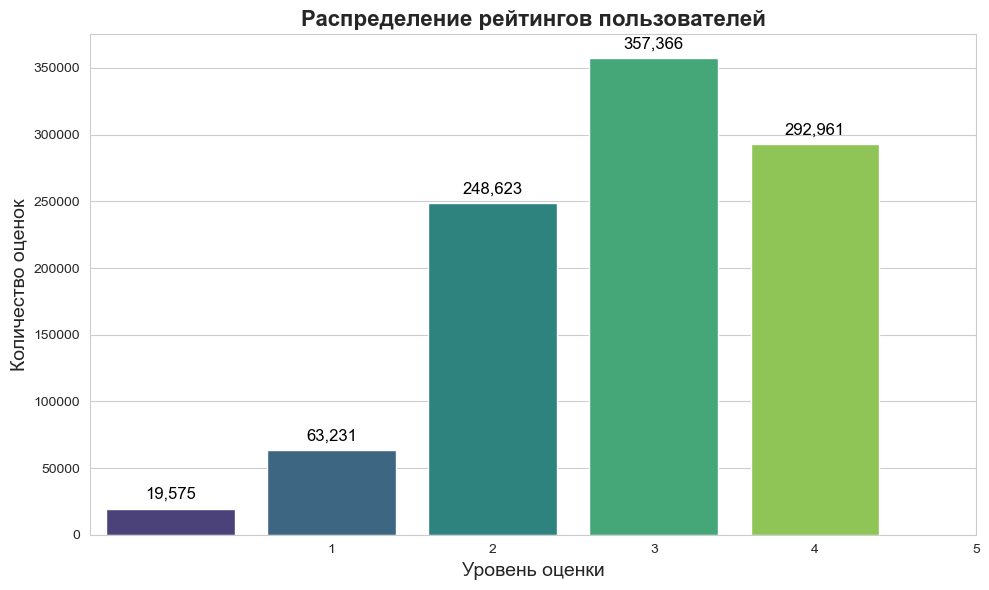

In [39]:
# Визуализация частоты оценок
sns.set_style("whitegrid")

# Создаем фигуру
plt.figure(figsize=(10, 6))

# Строим улучшенную countplot с кастомной палитрой
palette = sns.color_palette("viridis", len(user_reviews['rating'].unique()))
ax = sns.countplot(
    x='rating',
    hue='rating',  # Присваиваем x к hue для совместимости с будущими версиями Seaborn
    data=user_reviews,
    order=sorted(user_reviews['rating'].unique()),
    palette=palette,
    legend=False  # Убираем легенду, так как она не требуется для этого графика
)

# Добавляем заголовок и подписи осей
ax.set_title('Распределение рейтингов пользователей', fontsize=16, fontweight='bold')
ax.set_xlabel('Уровень оценки', fontsize=14)
ax.set_ylabel('Количество оценок', fontsize=14)

# Добавляем аннотации с подсчетом на каждом баре для лучшей читаемости
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',  # Форматируем число с разделителями
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        color='black',
        xytext=(0, 5),  # Смещение текста вверх
        textcoords='offset points'
    )

# Улучшаем разделители осей: четкие целые числа для рейтингов
ax.set_xticks(sorted(user_reviews['rating'].unique()))
ax.set_xticklabels(sorted(user_reviews['rating'].unique()))

# Показываем график
plt.tight_layout()  # Автоматически подгоняем layout
plt.show()

***Распределение показывает что большинство пользователей довольны***

In [30]:
# Разведочный анализ литературы
literature.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m/2767052.jpg,https://images.gr-assets.com/books/1447303603s/2767052.jpg
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m/3.jpg,https://images.gr-assets.com/books/1474154022s/3.jpg
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m/41865.jpg,https://images.gr-assets.com/books/1361039443s/41865.jpg
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,To Kill a Mockingbird,eng,4.25,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m/2657.jpg,https://images.gr-assets.com/books/1361975680s/2657.jpg
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,The Great Gatsby,eng,3.89,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m/4671.jpg,https://images.gr-assets.com/books/1490528560s/4671.jpg


*Напишем функцию для анализа данных по литературе*

In [40]:
def infoOut(df, details=False, missing_values=False):
    """
    Функция для получения информации о DataFrame.

    Args:
        df (pd.DataFrame): DataFrame для анализа.
        details (bool): Если True, возвращает расширенную информацию.
        missing_values (bool): Если True, возвращает информацию о пропущенных значениях.

    Returns:
        pd.DataFrame: DataFrame с информацией о столбцах.
    """
    dfInfo = df.columns.to_frame(name='Column')
    dfInfo['Missing Values'] = df.isnull().sum()
    dfInfo['%'] = round(df.isnull().sum() / len(df) * 100, 2)
    dfInfo['Dtype'] = df.dtypes

    # Подсчитываем общее количество дубликатов в dfFrame
    dfInfo['Duplicates'] = df.duplicated().sum()
    dfInfo['Unique Values'] = df.nunique()
    dfInfo['Total Rows'] = len(df)

    # Нормализуем данные: приводим к нижнему регистру и убираем пробелы
    df_normalized = df.astype(str).apply(lambda x: x.str.lower().str.strip())

    # Группируем по всем столбцам и считаем неявные дубликаты
    implicit_duplicates = df_normalized.groupby(list(df_normalized.columns)).size()

    # Записываем количество неявных дубликатов в dfInfo
    dfInfo['Implicit Duplicates'] = (implicit_duplicates > 1).sum()

    # Примерные значения для каждой колонки
    dfInfo['Example Values'] = df.apply(lambda x: ', '.join(map(str, x.unique()[:3].tolist())), axis=0)

    # Проверяем наличие дубликатов по выбранным столбцам, если их больше одного
    if df.shape[1] > 1:
        sample_columns = df.columns[1:3] # Выбираем первые два столбца для проверки
        dfInfo['Duplicates by Sample Columns'] = df.duplicated(subset=sample_columns).sum()
    else:
        dfInfo['Duplicates by Sample Columns'] = 0 # Если столбцов меньше двух, записываем 0

    dfInfo.reset_index(drop=True, inplace=True)

    if details:
        rangeIndex = df.index
        totalColumns = dfInfo['Column'].count()
        dtypesCount = dfInfo['Dtype'].value_counts()
        totalMemory = df.memory_usage().sum()
        if missing_values:
            return dfInfo, rangeIndex, totalColumns, dtypesCount, totalMemory, df.isnull().sum(), dfInfo['Duplicates']
        else:
            return dfInfo, rangeIndex, totalColumns, dtypesCount, totalMemory
    else:
        return dfInfo

In [41]:
# Выведем аналитическую табличку
# Анализируем literature
train_info = infoOut(literature, details=True, missing_values=True)
trainInfo = train_info[0]
train_totalColumns = train_info[2]
train_totalMemory = train_info[4]

# Добавляем индикатор дубликатов для каждой строки в dfFrame
trainInfo['Duplicate Rows'] = literature.duplicated()

display(trainInfo)
display(f"Total Columns: {train_totalColumns}")
print(f"Memory Usage: {train_totalMemory} bytes")

,Column,Missing Values,%,Dtype,Duplicates,Unique Values,Total Rows,Implicit Duplicates,Example Values,Duplicates by Sample Columns,Duplicate Rows
0,id,0,0.00,int64,0,10000,10000,0,"1, 2, 3",0,False
1,book_id,0,0.00,int64,0,10000,10000,0,"2767052, 3, 41865",0,False
2,best_book_id,0,0.00,int64,0,10000,10000,0,"2767052, 3, 41865",0,False
3,work_id,0,0.00,int64,0,10000,10000,0,"2792775, 4640799, 3212258",0,False
4,books_count,0,0.00,int64,0,597,10000,0,"272, 491, 226",0,False
5,isbn,700,7.00,object,0,9300,10000,0,"439023483, 439554934, 316015849",0,False
6,isbn13,585,5.85,float64,0,9153,10000,0,"9780439023480.0, 9780439554930.0, 9780316015840.0",0,False
7,authors,0,0.00,object,0,4664,10000,0,"Suzanne Collins, J.K. Rowling, Mary GrandPré, Stephenie Meyer",0,False
8,original_publication_year,21,0.21,float64,0,293,10000,0,"2008.0, 1997.0, 2005.0",0,False
9,original_title,0,0.00,object,0,9854,10000,0,"The Hunger Games, Harry Potter and the Philosopher's Stone, Twilight",0,False


'Total Columns: 23'

Memory Usage: 1840132 bytes


**Датасет без дубликатов и с низкими пропусками. Уникальность высокая. Также, стоит отметить одинаковое количество строк с user_reviews (по 10 000), что обеспечивает полные связи.**

In [44]:
# Заменим пустые значения
literature['original_title'] = literature['original_title'].fillna(literature['title'])

# Посмотрим статистику по числовым столбцам
numeric_columns = literature.select_dtypes(include=['float64', 'int64']).columns

print("Статистика для literature:\n")
display(literature[numeric_columns].describe())

Статистика для literature:



,id,book_id,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9.415000e+03,9979.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,9.755044e+12,1981.987674,4.002191,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,4.428619e+11,152.576665,0.254427,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,1.951703e+08,-1750.000000,2.470000,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,9.780316e+12,1990.000000,3.850000,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,9.780452e+12,2004.000000,4.020000,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,9.780831e+12,2011.000000,4.180000,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04
max,10000.00000,3.328864e+07,3.553423e+07,5.639960e+07,3455.000000,9.790008e+12,2017.000000,4.820000,4.780653e+06,4.942365e+06,155254.000000,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06


**Фокус на колонках: book_id, goodreads_book_id, authors, title — они выглядят корректно**

In [46]:
# Разведочный анализ тегов
# Выведем аналитическую табличку
train_info = infoOut(literature_keywords, details=True, missing_values=True)
trainInfo = train_info[0]
train_totalColumns = train_info[2]
train_totalMemory = train_info[4]

# Добавляем индикатор дубликатов для каждой строки в dfFrame
trainInfo['Duplicate Rows'] = literature_keywords.duplicated()

display(trainInfo)
display(f"Total Columns: {train_totalColumns}")
print(f"Memory Usage: {train_totalMemory} bytes")

,Column,Missing Values,%,Dtype,Duplicates,Unique Values,Total Rows,Implicit Duplicates,Example Values,Duplicates by Sample Columns,Duplicate Rows
0,goodreads_book_id,0,0.0,int64,6,10000,999912,6,"1, 2, 3",757903,False
1,tag_id,0,0.0,int64,6,34252,999912,6,"30574, 11305, 11557",757903,False
2,count,0,0.0,int64,6,9401,999912,6,"167697, 37174, 34173",757903,False


'Total Columns: 3'

Memory Usage: 23998020 bytes


**Данные практически без пропусков и с высокой уникальностью, что указывает на их высокое качество. Кроме того, goodreads_book_id и id обеспечивают идеальное 1:1 совпадение для join.** 